# ECG Arrhythmia Explorer

## Abstract

В данной работе проводится анализ электрокардиографических (ЭКГ) признаков на основе клинической базы данных PTB-XL. Исходный датасет объединяет две базы: PTB-XL (демографические данные и SCP-диагнозы) и PTB-XL+ (автоматически извлечённые числовые признаки ЭКГ), что позволяет анализировать связь между электрофизиологическими параметрами сердца и кардиологическими диагнозами. Основные направления исследования: дескриптивный анализ ключевых ЭКГ-параметров, сравнение методов коррекции QT-интервала, изучение электрофизиологического профиля фибрилляции предсердий

## Dataset Description

Данные получены из двух публичных источников PhysioNet:

- **PTB-XL** (v1.0.3) — 21 837 записей 12-отведенческих ЭКГ от 18 885 пациентов. Содержит демографические данные (возраст, пол), стратификационные метки и диагнозы в формате SCP-кодов с уровнями уверенности.
- **PTB-XL+** (v1.0.1) — расширение PTB-XL с автоматически извлечёнными числовыми признаками сигнала: ЧСС, интервалы, оси.

После объединения по `ecg_id` итоговый датасет содержит **21 799 записей** и **100 колонок**:

- **Демография:** `age`, `sex`
- **Временны́е интервалы:** `heart_rate`, `rr_mean`, `pr_interval`, `qrs_duration`, `qt_interval`
- **Коррекция QT:** `qtc_bazett`, `qtc_fridericia`, `qtc_framingham`
- **Электрические оси:** `p_axis`, `qrs_axis`, `t_axis`
- **P-волна:** `p_duration`, `p_found`
- **SCP-диагнозы:** ~70 бинарных колонок `scp_*`
- **Производные колонки:** `age_group`, `heart_rate_group`, `abnormal_flag`, `num_diagnoses`, `qtc_spread`, `axis_deviation`, `pr_missing`

## **Скачивание библиотеки wfdb для чтения медицинских показаний**

In [1]:
!pip install wfdb


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## **Импортирование нужных библиотек**

In [2]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import scipy
import ast

## **Скачивание базы данных**

In [3]:
# !wget -r -N -c -np "https://physionet.org/files/ptb-xl/1.0.3/records100/"

In [4]:
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/features/12sl_features.csv
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/features/feature_description.csv
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/labels/

## **Извлечение данных из баз данных**

In [4]:
ptb_xl = pd.read_csv("data/raw/ptb-xl/ptbxl_database.csv")
ptb_xlp = pd.read_csv("data/raw/ptb-xl+/features/12sl_features.csv")
scp_stat = pd.read_csv("data/raw/ptb-xl/scp_statements.csv")


# **Составление и очистка базы данных**

### Составление своей базы данных через merge двух нужных баз

In [5]:
selected_columns = ptb_xl[
    [
        "ecg_id",
        "patient_id",
        "age",
        "sex",
        "strat_fold",
        "filename_lr",
        "scp_codes"
    ]
]
selected_columns.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [6]:
selected_columns2 = ptb_xlp[
    [
    "ecg_id",
    "HR_Ventr_Global",
    "RR_Mean_Global",
    "QRS_Count_Global",
    "PR_Int_Global",
    "QRS_Dur_Global",
    "QT_Int_Global",
    "QT_IntCorr_Global",
    "QT_IntBazett_Global",
    "QT_IntFridericia_Global",
    "QT_IntFramingham_Global",
    "P_AxisFront_Global",
    "R_AxisFrontal_Global",
    "T_AxisFront_Global",
    "P_Dur_Global",
    "P_Found_Global"
]]
selected_columns2 = selected_columns2.rename(columns={
    "HR_Ventr_Global": "heart_rate",
    "RR_Mean_Global": "rr_mean",
    "QRS_Count_Global": "qrs_count",
    "PR_Int_Global": "pr_interval",
    "QRS_Dur_Global": "qrs_duration",
    "QT_Int_Global": "qt_interval",
    "QT_IntCorr_Global": "qtc_corrected",
    "QT_IntBazett_Global": "qtc_bazett",
    "QT_IntFridericia_Global": "qtc_fridericia",
    "QT_IntFramingham_Global": "qtc_framingham",
    "P_AxisFront_Global": "p_axis",
    "R_AxisFrontal_Global": "qrs_axis",
    "T_AxisFront_Global": "t_axis",
    "P_Dur_Global": "p_duration",
    "P_Found_Global": "p_found"
})

main = pd.read_csv("data/processed/ecg_research_dataset.csv")
merge = main.merge(selected_columns2, on="ecg_id", how="right")
merge.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [7]:
data = pd.read_csv("data/processed/ecg_research_dataset.csv")
data = data.drop(columns=["sex_y", "patient_id_y","age_y","sex_y","strat_fold_y","filename_lr_y","scp_codes_y"])
rename_columns = {i : i[:-2] for i in data.columns if i[-1] == "x" and i[-2] == "_"}
data = data.rename(columns=rename_columns)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)


KeyError: "['sex_y', 'patient_id_y', 'age_y', 'sex_y', 'strat_fold_y', 'filename_lr_y', 'scp_codes_y'] not found in axis"

In [8]:
data = pd.read_csv("data/processed/ecg_research_dataset.csv")
data = data.drop(columns=data.columns[:2])
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [9]:
codes = data["scp_codes"].apply(ast.literal_eval)
scp_data = pd.json_normalize(codes).fillna(0)
scp_data = scp_data.add_prefix("scp_")
data = pd.concat([data, scp_data], axis=1)
def abnormal(x):
    active = [k for k, v in x.items() if v > 0]
    return 0 if active == ["NORM"] else 1
data['abnormal_flag'] = codes.apply(abnormal)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [ ]:
data["num_diagnoses"] = codes.apply(lambda x: sum(1 for v in x.values() if v > 0))
def ages(x):
    if x < 35: return "young"
    if x < 60: return "middle"
    return "senior"
data["age_group"] = data["age"].apply(ages)

,ecg_id,patient_id,age,sex,strat_fold,filename_lr,scp_codes,heart_rate,rr_mean,qrs_count,...,scp_INJIL,scp_2AVB,scp_PRC(S),scp_PSVT,scp_PMI,scp_STE_,scp_WPW,scp_INJIN,num_diagnoses,age_group
0,1,15709.0,56.0,1,3,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",64.0,938.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,middle
1,21803,12842.0,87.0,1,2,records100/21000/21803_lr,"{'CRBBB': 100.0, 'SARRH': 0.0}",75.0,802.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
2,21804,12842.0,87.0,1,2,records100/21000/21804_lr,"{'CRBBB': 100.0, 'AFIB': 0.0}",169.0,354.0,27.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
3,21805,16291.0,72.0,0,3,records100/21000/21805_lr,"{'ASMI': 100.0, 'ISCAL': 100.0, 'LAFB': 100.0,...",79.0,756.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,senior
4,21806,20136.0,85.0,0,5,records100/21000/21806_lr,"{'NDT': 100.0, 'SR': 0.0}",92.0,650.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21794,21834,20703.0,300.0,0,4,records100/21000/21834_lr,"{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}",67.0,894.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
21795,21835,19311.0,59.0,1,2,records100/21000/21835_lr,"{'ISCAS': 50.0, 'SR': 0.0}",59.0,1022.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,middle
21796,21836,8873.0,64.0,1,8,records100/21000/21836_lr,"{'NORM': 100.0, 'SR': 0.0}",70.0,858.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior
21797,21837,11744.0,68.0,0,9,records100/21000/21837_lr,"{'NORM': 100.0, 'SR': 0.0}",59.0,1012.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,senior


### Нужно понять, как определить heart_rate_group. Для этого сначала построим визуализацию и разнесем в 3 группы: bradycardia, normal_hr, tachycardia

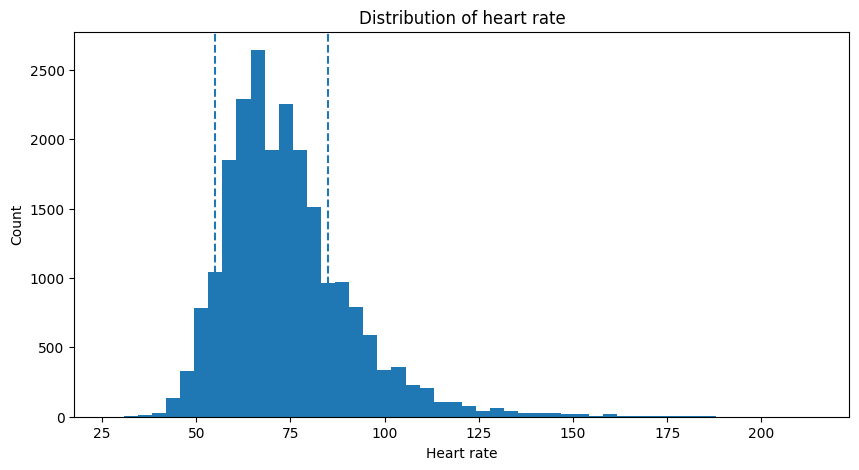

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(data["heart_rate"].dropna(), bins=50)
plt.xlabel("Heart rate")
plt.ylabel("Count")
plt.title("Distribution of heart rate")
plt.axvline(55, linestyle="--", label="HR = 60")
plt.axvline(85, linestyle="--", label="HR = 100")
plt.show()

In [11]:
def hrg(x):
    if x < 55: return "bradycardia"
    if x < 85: return "normal_hr"
    return "tachycardia"
data["heart_rate_group"] = data["heart_rate"].apply(hrg)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [14]:
data = pd.read_csv("data/processed/ecg_research_dataset.csv")
data['qtc_spread'] = (
    data[['qtc_bazett', 'qtc_fridericia', 'qtc_framingham']].max(axis=1)
    - data[['qtc_bazett', 'qtc_fridericia', 'qtc_framingham']].min(axis=1)
)
def classify_axis(x):
    if pd.isna(x):
        return 'unknown'
    if -30 <= x <= 90:
        return 'normal'
    elif x < -30:
        return 'left_deviation'
    else:
        return 'right_deviation'
data["axis_deviation"] = data["qrs_axis"].apply(classify_axis)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)
print(data[['qtc_bazett', 'qtc_fridericia', 'qtc_framingham', 'qtc_spread']].describe())
print("\nDistribution axis_deviation:")
print(data['axis_deviation'].value_counts())

         qtc_bazett  qtc_fridericia  qtc_framingham    qtc_spread
count  21799.000000    21799.000000    21799.000000  21799.000000
mean     433.060874      419.879765      419.590027     19.274003
std       33.127046       29.032658       27.520224     17.483077
min      176.000000      160.000000      201.000000      0.000000
25%      412.000000      402.000000      403.000000      8.000000
50%      430.000000      417.000000      417.000000     15.000000
75%      450.000000      434.000000      433.000000     26.000000
max      841.000000      809.000000      694.000000    393.000000

Distribution axis_deviation:
axis_deviation
normal             18895
left_deviation      2437
right_deviation      466
unknown                1
Name: count, dtype: int64


В датасет добавлены следующие производные колонки:

| Колонка | Тип | Описание |
|---|---|---|
| `abnormal_flag` | int (0/1) | 1 = есть патологический диагноз |
| `num_diagnoses` | int | Число активных SCP-диагнозов |
| `age_group` | str | young / middle / senior |
| `heart_rate_group` | str | bradycardia / normal_hr / tachycardia |
| `pr_missing` | int (0/1) | 1 = PR-интервал не измерим (нет P-волны) |
| `qtc_spread` | float | Разброс между Bazett, Fridericia, Framingham (мс) |
| `axis_deviation` | str | normal / left_deviation / right_deviation |

### Data cleanup preparation

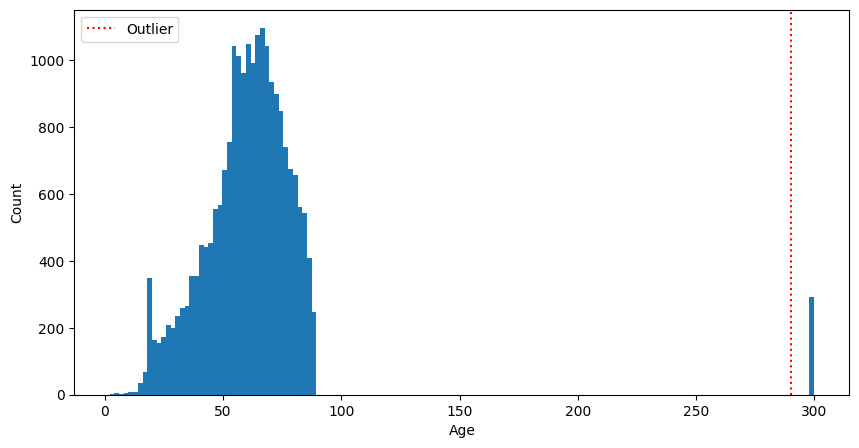

In [16]:
plt.figure(figsize=(10,5))
plt.hist(data["age"].dropna(), bins = 150)
plt.xlabel("Age")
plt.ylabel("Count")
plt.axvline(290, color="red", label="Outlier", linestyle=":")
plt.legend()
plt.show()

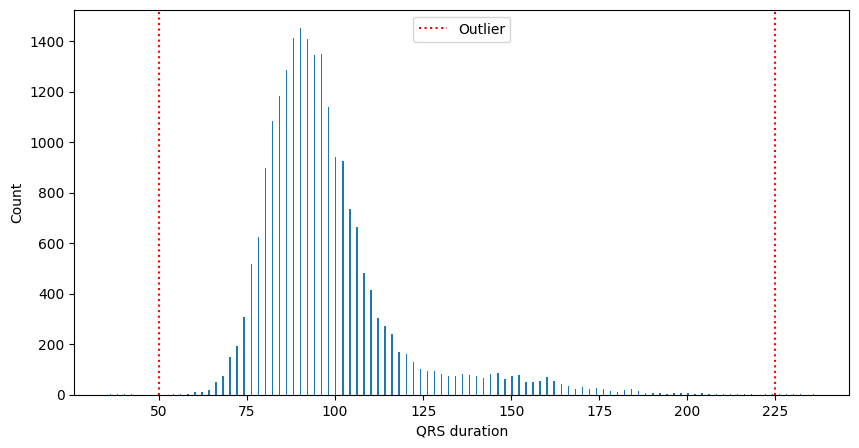

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(data["qrs_duration"].dropna(), bins = 500)
plt.xlabel("QRS duration")
plt.ylabel("Count")
plt.axvline(225, linestyle=":", color = "red", label="Outlier")
plt.axvline(50, linestyle=":", color = "red")
plt.legend()
plt.show()

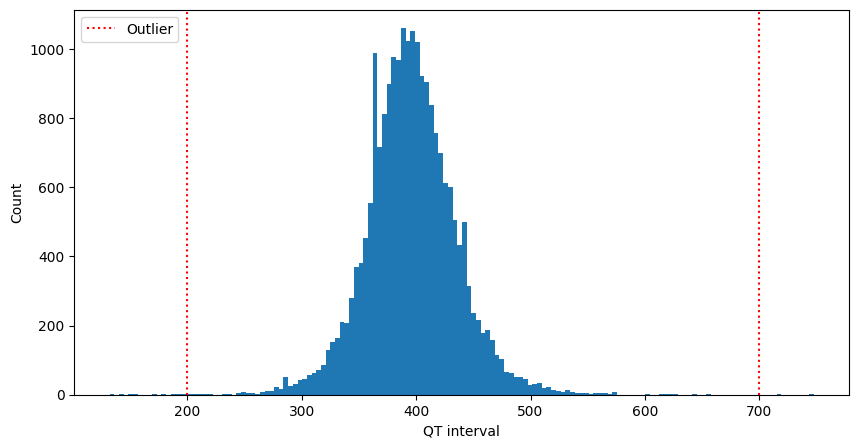

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(data["qt_interval"].dropna(), bins = 150)
plt.xlabel("QT interval")
plt.ylabel("Count")
plt.axvline(200, label="Outlier", linestyle=":", color="red")
plt.axvline(700, linestyle=":", color="red")
plt.legend()
plt.show()

In [18]:
for col in data.columns:
    sm = data[col].isna().sum()
    if sm > 0:
        print(f"{col}: {sm}")

pr_interval: 2013
p_axis: 1994
qrs_axis: 1
t_axis: 4
p_duration: 2032


### Data pre-cleanup

In [26]:
cdata = data.copy()
n0 = len(cdata)
cdata = cdata[cdata["age"] <= 120]
key_cols = ['heart_rate', 'rr_mean', 'qrs_duration', 'qt_interval',
            'qtc_bazett', 'qtc_fridericia', 'qtc_framingham', 'qrs_axis', 'age']
cdata = cdata.dropna(subset=key_cols)
cdata = cdata[
    cdata['heart_rate'].between(20, 300) &
    cdata['qrs_duration'].between(50, 225) &
    cdata['qt_interval'].between(200, 700) &
    cdata['rr_mean'].between(200, 3000)
]
cdata.to_csv("data/processed/cleaned_ecg_dataset.csv", index=False)
print(f"Deleted {n0 - len(cdata)} rows (from {n0} to {len(cdata)})")

Deleted 320 rows (from 21799 to 21479)


In [27]:
cdata = cdata.dropna(subset=["qrs_axis"])
cdata = cdata.dropna(subset=["t_axis"])
cdata['pr_missing'] = cdata['pr_interval'].isna().astype(int)
cdata["pr_interval"] = cdata["pr_interval"].fillna(0)


In [28]:
no_p = cdata['p_found'] == 0
no_pr = cdata['pr_interval'] == 0
print("Нет P-волны:", no_p.sum())
print("Нет PR:", no_pr.sum())  
print("Совпадают:", (no_p & no_pr).sum())

Нет P-волны: 1957
Нет PR: 1910
Совпадают: 1782
